# Imports 

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

nnfs.init()


# DEVICE


In [3]:


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


# Data 

In [6]:


X, y = spiral_data(samples=1000, classes=3)

X = torch.tensor(X, dtype=torch.float32).to(device)

y = torch.tensor(y, dtype=torch.long).to(device)

# PLot the data 

X shape: torch.Size([3000, 2])
y shape: torch.Size([3000])


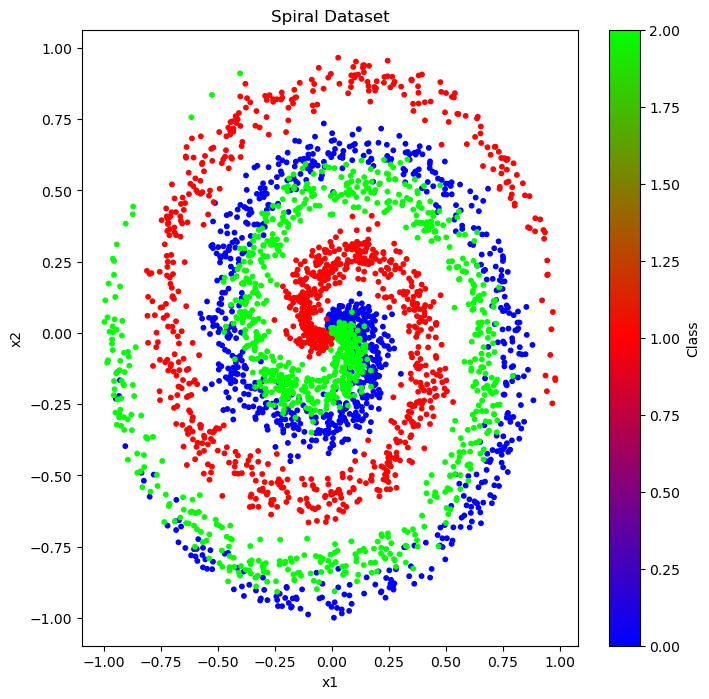

In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)

# scatter plot
plt.figure(figsize=(8,8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="brg",
    s=10
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Spiral Dataset")

plt.colorbar(label="Class")

plt.show()

# ============================================================
# HYPERPARAMETERS
# ============================================================

In [7]:


INPUT_DIM = 2
HIDDEN_DIM = 64
OUTPUT_DIM = 3

EPOCHS = 5000
BATCH_SIZE = 32

optimizer_name = "adamw"

# ============================================================
# DATA LOADER
# ============================================================

In [8]:


dataset = torch.utils.data.TensorDataset(X, y)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# ============================================================
# MODEL
# ============================================================

In [9]:


class NeuralNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(INPUT_DIM, HIDDEN_DIM),

            nn.ReLU(),

            nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        )

    def forward(self, x):

        return self.net(x)

model = NeuralNet().to(device)

# LOSS

In [10]:


criterion = nn.CrossEntropyLoss()


# ============================================================
# OPTIMIZER
# ============================================================

In [11]:


if optimizer_name == "gd":

    optimizer = optim.SGD(
        model.parameters(),
        lr=1.0
    )

elif optimizer_name == "rmsprop":

    optimizer = optim.RMSprop(
        model.parameters(),
        lr=0.01
    )

elif optimizer_name == "adagrad":

    optimizer = optim.Adagrad(
        model.parameters(),
        lr=0.5
    )

elif optimizer_name == "adam":

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.01
    )

elif optimizer_name == "adamw":

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.01,
        weight_decay=1e-4
    )



# ============================================================
# ACCURACY FUNCTION
# ============================================================

In [12]:


def accuracy(logits, labels):

    pred = torch.argmax(logits, dim=1)

    acc = (pred == labels).float().mean()

    return acc.item()

# ============================================================
# TRAINING
# ============================================================

In [13]:


losses = []

for epoch in range(EPOCHS):

    model.train()

    for X_batch, y_batch in loader:

        # --------------------------------------------
        # forward
        # --------------------------------------------

        logits = model(X_batch)

        loss = criterion(logits, y_batch)

        # --------------------------------------------
        # backward
        # --------------------------------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    losses.append(loss.item())

    # --------------------------------------------
    # evaluation
    # --------------------------------------------

    if epoch % 500 == 0:

        model.eval()

        with torch.no_grad():

            full_logits = model(X)

            acc = accuracy(full_logits, y)

        print(
            f"epoch={epoch} "
            f"loss={loss.item():.4f} "
            f"acc={acc:.4f}"
        )


epoch=0 loss=1.0754 acc=0.3983
epoch=500 loss=0.2894 acc=0.8917
epoch=1000 loss=0.1363 acc=0.9000
epoch=1500 loss=0.2918 acc=0.8937
epoch=2000 loss=0.2611 acc=0.8963
epoch=2500 loss=0.5119 acc=0.8993
epoch=3000 loss=0.4088 acc=0.8990
epoch=3500 loss=0.1538 acc=0.8953
epoch=4000 loss=0.2450 acc=0.9067
epoch=4500 loss=0.2036 acc=0.9073


# ============================================================
# LOSS CURVE
# ============================================================

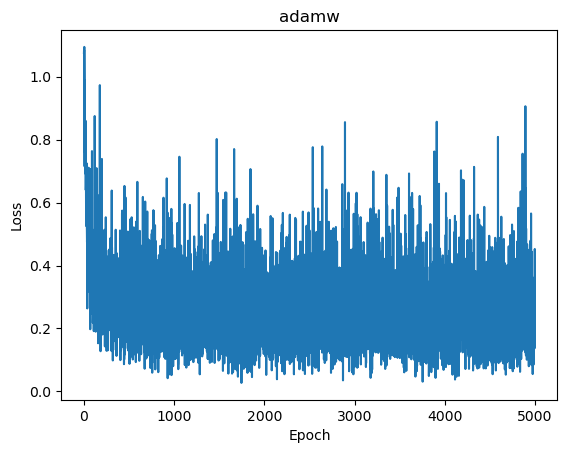

In [14]:


plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(optimizer_name)

plt.show()

# ============================================================
# DECISION BOUNDARY
# ============================================================

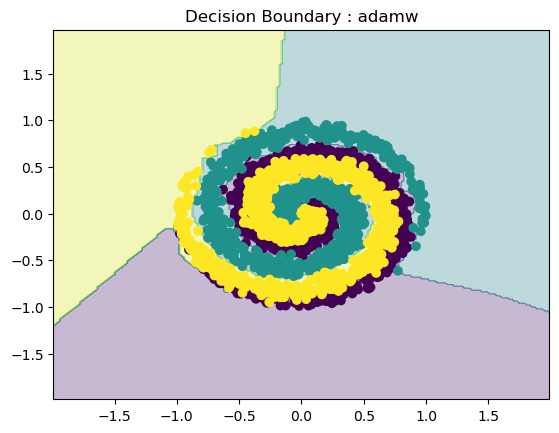

In [15]:


h = 0.02

x_min, x_max = (
    X[:,0].min().item()-1,
    X[:,0].max().item()+1
)

y_min, y_max = (
    X[:,1].min().item()-1,
    X[:,1].max().item()+1
)

xx, yy = np.meshgrid(

    np.arange(x_min, x_max, h),

    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.tensor(
    grid,
    dtype=torch.float32
).to(device)

model.eval()

with torch.no_grad():

    logits = model(grid_tensor)

    pred = torch.argmax(logits, dim=1)

Z = pred.cpu().numpy().reshape(xx.shape)

# ============================================================
# PLOT
# ============================================================

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:,0].cpu(),
    X[:,1].cpu(),
    c=y.cpu()
)

plt.title(f"Decision Boundary : {optimizer_name}")

plt.show()

# Everything put together in pytorch ..

Using device: cpu
epoch=0 loss=1.0467 acc=0.3933
epoch=500 loss=0.4116 acc=0.8977
epoch=1000 loss=0.1370 acc=0.9053
epoch=1500 loss=0.2662 acc=0.9130
epoch=2000 loss=0.2476 acc=0.9087
epoch=2500 loss=0.3473 acc=0.9153
epoch=3000 loss=0.2415 acc=0.9123
epoch=3500 loss=0.5140 acc=0.9173
epoch=4000 loss=0.1761 acc=0.9100
epoch=4500 loss=0.2759 acc=0.9083


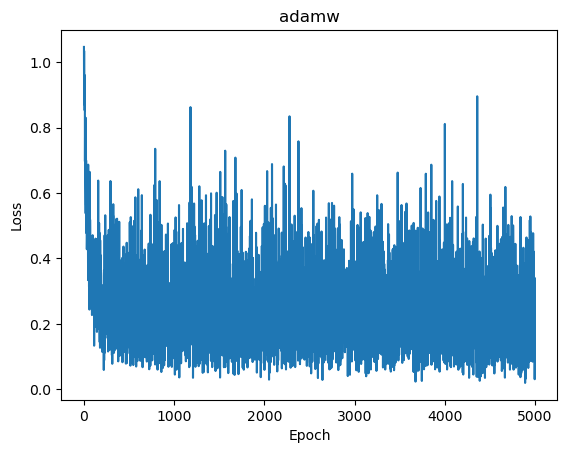

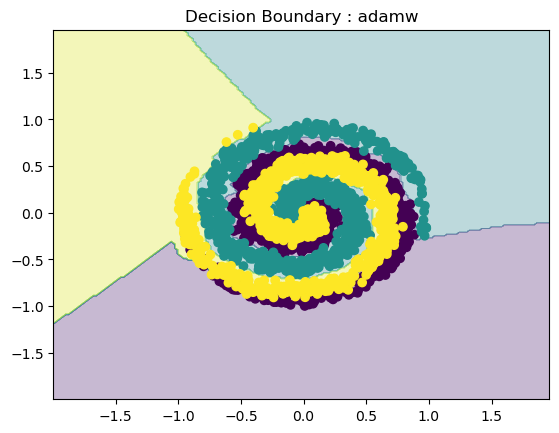

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

nnfs.init()

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# ============================================================
# DATA
# ============================================================

X, y = spiral_data(samples=1000, classes=3)

X = torch.tensor(X, dtype=torch.float32).to(device)

y = torch.tensor(y, dtype=torch.long).to(device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

INPUT_DIM = 2
HIDDEN_DIM = 64
OUTPUT_DIM = 3

EPOCHS = 5000
BATCH_SIZE = 32

optimizer_name = "adamw"

# ============================================================
# DATA LOADER
# ============================================================

dataset = torch.utils.data.TensorDataset(X, y)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ============================================================
# MODEL
# ============================================================

class NeuralNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(INPUT_DIM, HIDDEN_DIM),

            nn.ReLU(),

            nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        )

    def forward(self, x):

        return self.net(x)

model = NeuralNet().to(device)

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

if optimizer_name == "gd":

    optimizer = optim.SGD(
        model.parameters(),
        lr=1.0
    )

elif optimizer_name == "rmsprop":

    optimizer = optim.RMSprop(
        model.parameters(),
        lr=0.01
    )

elif optimizer_name == "adagrad":

    optimizer = optim.Adagrad(
        model.parameters(),
        lr=0.5
    )

elif optimizer_name == "adam":

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.01
    )

elif optimizer_name == "adamw":

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.01,
        weight_decay=1e-4
    )

# ============================================================
# ACCURACY FUNCTION
# ============================================================

def accuracy(logits, labels):

    pred = torch.argmax(logits, dim=1)

    acc = (pred == labels).float().mean()

    return acc.item()

# ============================================================
# TRAINING
# ============================================================

losses = []

for epoch in range(EPOCHS):

    model.train()

    for X_batch, y_batch in loader:

        # --------------------------------------------
        # forward
        # --------------------------------------------

        logits = model(X_batch)

        loss = criterion(logits, y_batch)

        # --------------------------------------------
        # backward
        # --------------------------------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    losses.append(loss.item())

    # --------------------------------------------
    # evaluation
    # --------------------------------------------

    if epoch % 500 == 0:

        model.eval()

        with torch.no_grad():

            full_logits = model(X)

            acc = accuracy(full_logits, y)

        print(
            f"epoch={epoch} "
            f"loss={loss.item():.4f} "
            f"acc={acc:.4f}"
        )

# ============================================================
# LOSS CURVE
# ============================================================

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(optimizer_name)

plt.show()

# ============================================================
# DECISION BOUNDARY
# ============================================================

h = 0.02

x_min, x_max = (
    X[:,0].min().item()-1,
    X[:,0].max().item()+1
)

y_min, y_max = (
    X[:,1].min().item()-1,
    X[:,1].max().item()+1
)

xx, yy = np.meshgrid(

    np.arange(x_min, x_max, h),

    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.tensor(
    grid,
    dtype=torch.float32
).to(device)

model.eval()

with torch.no_grad():

    logits = model(grid_tensor)

    pred = torch.argmax(logits, dim=1)

Z = pred.cpu().numpy().reshape(xx.shape)

# ============================================================
# PLOT
# ============================================================

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:,0].cpu(),
    X[:,1].cpu(),
    c=y.cpu()
)

plt.title(f"Decision Boundary : {optimizer_name}")

plt.show()